# **Live Coding BAB 6 Algoritma Prediksi Menggunakan Regresi**

- Nama    : Sayyidah Fatimah Azzahra
- NIM     : 235150200111064
- Kelas   : TIF-E

## **1. Import Library**

In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## **2. Dataset Preparation**

In [44]:
df = pd.read_csv('../dataset/nyc-east-river-bicycle-counts.csv')
df.head()

,Unnamed: 0,Date,Day,High Temp (°F),Low Temp (°F),Precipitation,Brooklyn Bridge,Manhattan Bridge,Williamsburg Bridge,Queensboro Bridge,Total
0,0,2016-04-01 00:00:00,2016-04-01 00:00:00,78.1,66.0,0.01,1704.0,3126,4115.0,2552.0,11497
1,1,2016-04-02 00:00:00,2016-04-02 00:00:00,55.0,48.9,0.15,827.0,1646,2565.0,1884.0,6922
2,2,2016-04-03 00:00:00,2016-04-03 00:00:00,39.9,34.0,0.09,526.0,1232,1695.0,1306.0,4759
3,3,2016-04-04 00:00:00,2016-04-04 00:00:00,44.1,33.1,0.47 (S),521.0,1067,1440.0,1307.0,4335
4,4,2016-04-05 00:00:00,2016-04-05 00:00:00,42.1,26.1,0,1416.0,2617,3081.0,2357.0,9471


In [45]:
# Bersihkan kolom Precipitation
df['Precipitation'] = df['Precipitation'].str.extract(r'([0-9.]+)').astype(float)

# Hapus kolom tidak penting
df = df.drop(columns=['Unnamed: 0', 'Date', 'Day'])

### **Atasi Null Values**

In [46]:
print(df.isna().sum())

High Temp (°F)         0
Low Temp (°F)          0
Precipitation          7
Brooklyn Bridge        0
Manhattan Bridge       0
Williamsburg Bridge    0
Queensboro Bridge      0
Total                  0
dtype: int64


In [47]:
clean_df = df.dropna()

## **3. Regresi Linear**

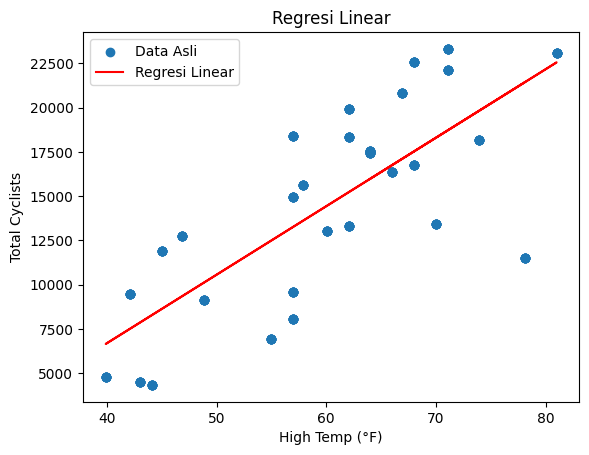

In [48]:
# Variabel independen dan dependen
x = clean_df['High Temp (°F)'].values
y = clean_df['Total'].values

# Hitung slope (m) dan intercept (b)
n = len(x)
x_mean = np.mean(x)
y_mean = np.mean(y)

numerator = np.sum((x - x_mean) * (y - y_mean))
denominator = np.sum((x - x_mean) ** 2)
m = numerator / denominator
b = y_mean - m * x_mean

# Prediksi
y_pred = m * x + b

# Plot
plt.scatter(x, y, label='Data Asli')
plt.plot(x, y_pred, color='red', label='Regresi Linear')
plt.xlabel('High Temp (°F)')  # nama kolom yang dipakai
plt.ylabel("Total Cyclists")
plt.title("Regresi Linear")
plt.legend()

## **3. Regresi Polinomial**

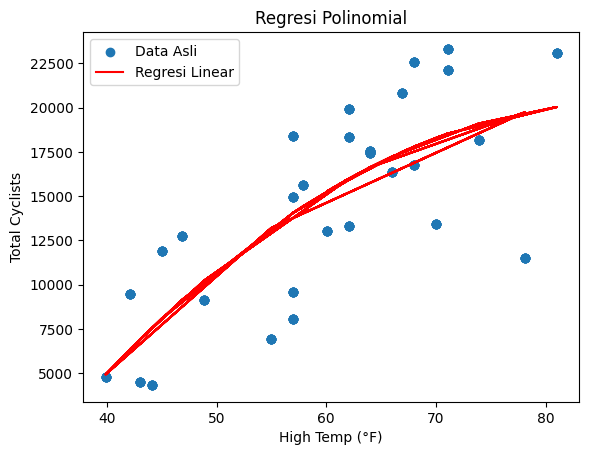

In [49]:
x = clean_df['High Temp (°F)'].values
y = clean_df['Total'].values

n = len(x)
x_flat = x.flatten() 

# Buat x^2
x_poly = np.column_stack((np.ones(n), x, x**2))

# Normal Equation: β = (XᵀX)^-1 Xᵀy
beta = np.linalg.inv(x_poly.T @ x_poly) @ x_poly.T @ y

# Prediksi
y_poly_pred = x_poly @ beta

# Plot
plt.scatter(x, y, label='Data Asli')
plt.plot(x, y_poly_pred, color='red', label='Regresi Linear')
plt.xlabel('High Temp (°F)') # isi dengan nama kolom yang dipakai
plt.ylabel("Total Cyclists")
plt.title("Regresi Polinomial")
plt.legend()
plt.show()

## **4. Regresi Multivariabel**

In [50]:
clean_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 203 entries, 0 to 209
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   High Temp (°F)       203 non-null    float64
 1   Low Temp (°F)        203 non-null    float64
 2   Precipitation        203 non-null    float64
 3   Brooklyn Bridge      203 non-null    float64
 4   Manhattan Bridge     203 non-null    int64  
 5   Williamsburg Bridge  203 non-null    float64
 6   Queensboro Bridge    203 non-null    float64
 7   Total                203 non-null    int64  
dtypes: float64(6), int64(2)
memory usage: 14.3 KB


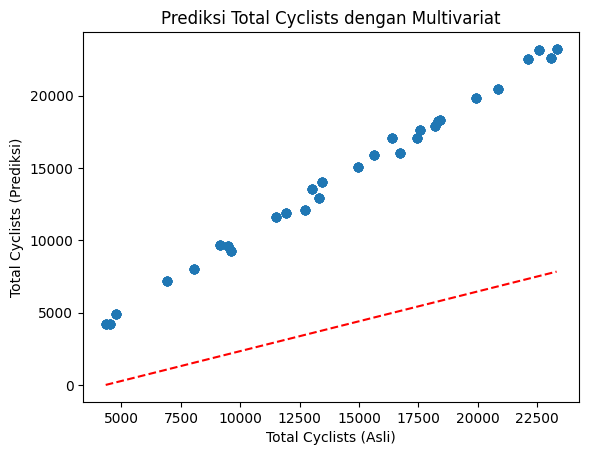

In [51]:
# Ambil tiga fitur
X_multi = clean_df[['High Temp (°F)', 'Low Temp (°F)', 'Williamsburg Bridge']].values  # pilih 3 kolom dari dataset
X_multi = np.column_stack((np.ones(X_multi.shape[0]), X_multi))  # tambah bias (intercept)
y_multi = clean_df['Total'].values

# Normal Equation
beta_multi = np.linalg.inv(X_multi.T @ X_multi) @ X_multi.T @ y_multi

# Prediksi
y_multi_pred = X_multi @ beta_multi

# Plot
plt.scatter(y_multi, y_multi_pred)
plt.xlabel("Total Cyclists (Asli)")
plt.ylabel("Total Cyclists (Prediksi)")
plt.title("Prediksi Total Cyclists dengan Multivariat")
plt.plot([y_multi.min(), y_multi.max()], [X_multi.min(), X_multi.max()], 'r--')
plt.show()

## **5. Pertanyaan**
1. Mengapa penting untuk memeriksa nilai-nilai kosong (NaN) dalam data sebelum melakukan analisis regresi? Apa dampaknya terhadap hasil model jika data tidak dibersihkan?
2. Jelaskan secara singkat perbedaan antara regresi linear sederhana, regresi polinomial, dan regresi multivariat. Dalam kasus seperti apa masing-masing jenis regresi lebih tepat digunakan?

**Jawaban**
1. Penting untuk memeriksa NaN karena NaN dampaknya dapat menyebabkan error saat kalkulasi atau hasil model yang tidak valid atau bisa jadi bias pada hasil prediksi, dan mempengaruhi akurasi model karena perhitungan seperti mean, slope, dan intercept yang bakal terganggu. Padahal, misalnya, di model regresi, perhitungan-perhitungan seperti itu akan sangat digunakan.

2. Jawaban no. 2 adalah sebagai berikut:

a. Regresi Linear:
- Menggunakan satu variabel independen dengan perhitungan manual slope dan intercept
- Cocok untuk hubungan sederhana dan linear antara dua variabel, seperti memprediksi total cyclists berdasarkan suhu cuaca.

b. Regresi Polinomial:
- Menggunakan matriks polinomial dan normal equation dengan menambahka komponen pangkat x^2
- Cocok untuk data yang memiliki pola kurva, seperti suhu yang mungkin memiliki puncak optimal terhadap jumlah cyclists

c. Regresi Multivariat:
- Menggunakan beberapa variabel independen dengan normal equation
- Cocok untuk kasus kompleks di mana banyak faktor mempengaruhi hasil, seperti jumlah cyclists yang dipengaruhi oleh suhu tinggi, suhu rendah, dan curah hujan sekaligus

Singkatnya, perbedaan tiap implementasi regresi terlihat dari jumlah variabel yang digunakan, metode perhitungan (rumus slope-intercept manual hingga penggunaan normal equation), dan kompleksitas model.